In [2]:
# Load the tidyverse packages

if (!require("tidyverse")) {
    install.packages("tidyverse")
}

suppressMessages(library(tidyverse))

# Download and read the data
dt <- read_delim("https://github.com/febse/data/raw/refs/heads/main/econ/invoices.txt")

dt |> head()

Loading required package: tidyverse

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─

Day,Invoices,Time
<dbl>,<dbl>,<dbl>
1,149,2.1
2,60,1.8
3,188,2.3
4,23,0.8
5,201,2.7
6,58,1.0


Variables description:

-   `Day` (numeric): day (1 to 30)
-   `Invoices` (numeric): number of invoices
-   `Time` (numeric): Time needed to process the invoices (hours)

[Desmos](https://www.desmos.com/calculator/twzjevedu5)

In [4]:
dt |> summary()

      Day           Invoices          Time      
 Min.   : 1.00   Min.   : 23.0   Min.   :0.800  
 1st Qu.: 8.25   1st Qu.: 62.5   1st Qu.:1.500  
 Median :15.50   Median :127.5   Median :2.000  
 Mean   :15.50   Mean   :130.0   Mean   :2.110  
 3rd Qu.:22.75   3rd Qu.:189.5   3rd Qu.:2.775  
 Max.   :30.00   Max.   :289.0   Max.   :4.100  

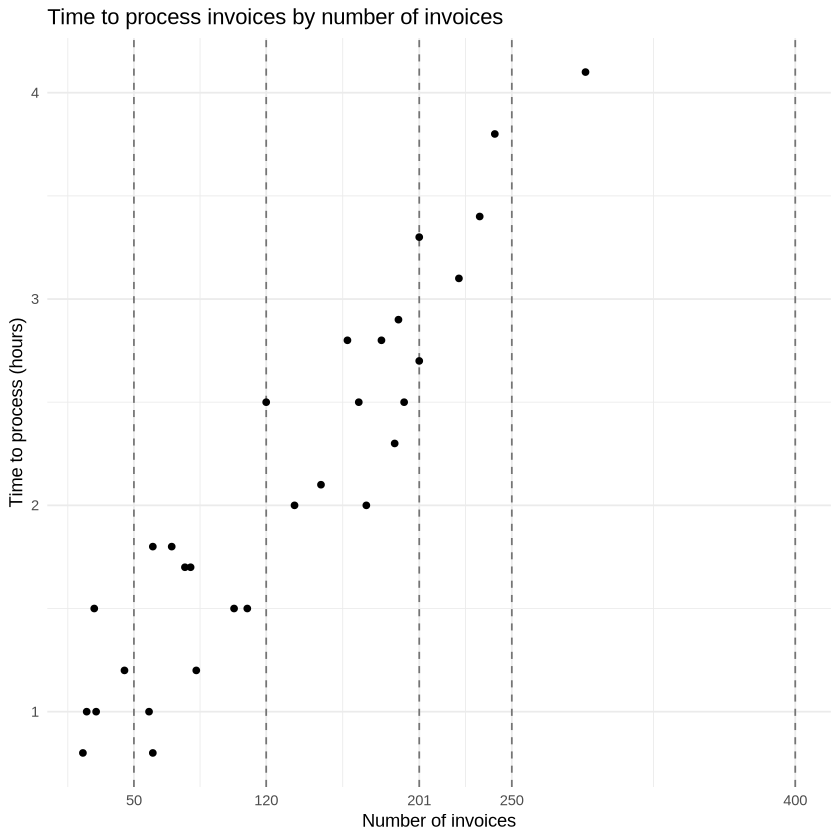

In [7]:
dt %>%
  ggplot(aes(x = Invoices, y = Time)) +
    geom_point() +
    geom_vline(xintercept = c(50, 120, 201, 250, 400), lty = 2, alpha = 0.5) +
    scale_x_continuous(breaks = c(50, 120, 201, 250, 400)) + 
    labs(title = "Time to process invoices by number of invoices",
         x = "Number of invoices",
         y = "Time to process (hours)") +
    theme_minimal()

## Prediction strategies

Strategy 1: Use the average processing time for the predictions

$$
\widehat{\text{Time}}_i^{(1)} = \overline{\text{Time}}
$$

Strategy 2: Use the following linear equation for the predictions

$$
\widehat{\text{Time}}_i^{(2)} = 0.6 + 0.01 \cdot \text{Invoices}_i
$$

In [9]:
dt <- dt %>%
    mutate(
        Time_predicted_1 = mean(Time),
        residuals_1 = Time - Time_predicted_1,
        Time_predicted_2 = 0.6 + 0.01 * Invoices,
        residuals_2 = Time - Time_predicted_2
    )

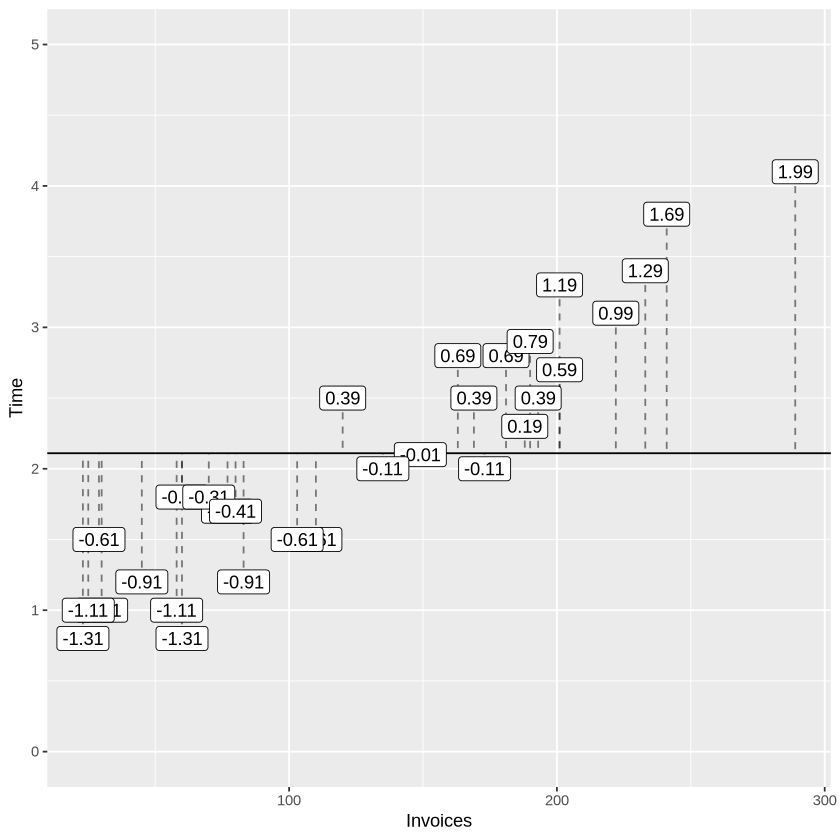

In [10]:
#| label: fig-residuals-strategy-1
#| fig-cap: "Prediction and Residuals for Strategy 1"
#| code-fold: true

dt %>%
    mutate(
        Time_predicted = mean(Time),
        residuals = Time - Time_predicted
    ) %>%
    ggplot(aes(x = Invoices, y = Time)) +
    geom_point() +
    geom_hline(yintercept = mean(dt$Time), lty = 1) +
    ylim(c(0, 5)) +
    geom_segment(
        aes(
            xend = Invoices,
            yend = mean(dt$Time)
            ), 
            lty = 2,
            alpha = 0.5
        ) +
    geom_label(aes(label = round(residuals, 2)))

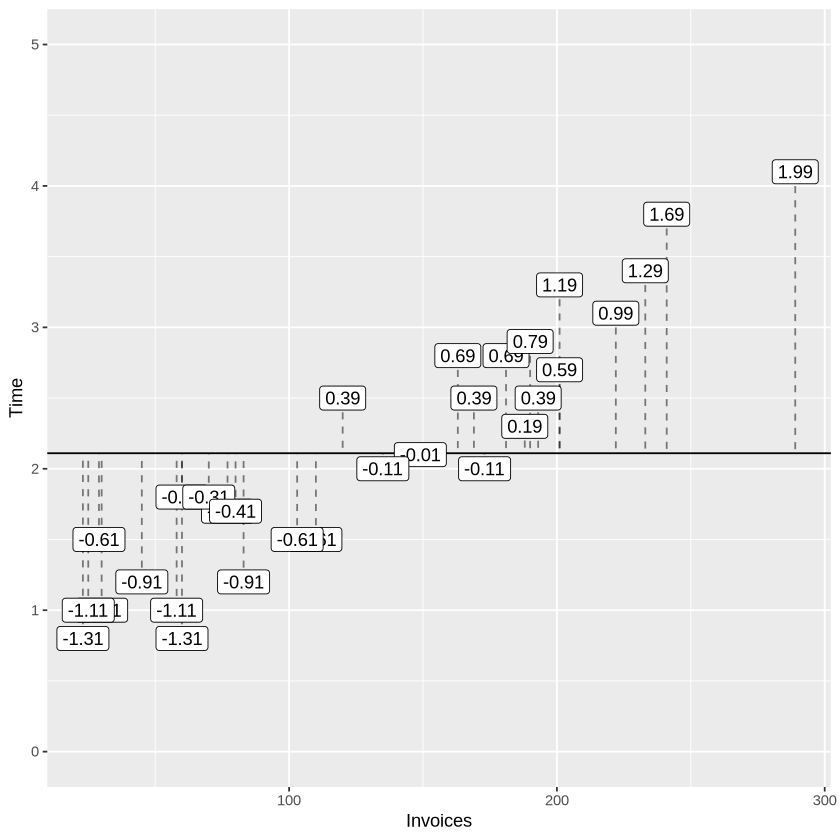

In [11]:
dt |>
    mutate(
        Time_predicted = mean(Time),
        residuals = Time - Time_predicted
    ) |>
    ggplot(aes(x = Invoices, y = Time)) +
    geom_point() +
    geom_hline(yintercept = mean(dt$Time), lty = 1) +
    ylim(c(0, 5)) +
    geom_segment(
        aes(
            xend = Invoices,
            yend = mean(dt$Time)
            ), 
            lty = 2,
            alpha = 0.5
        ) +
    geom_label(aes(label = round(residuals, 2)))

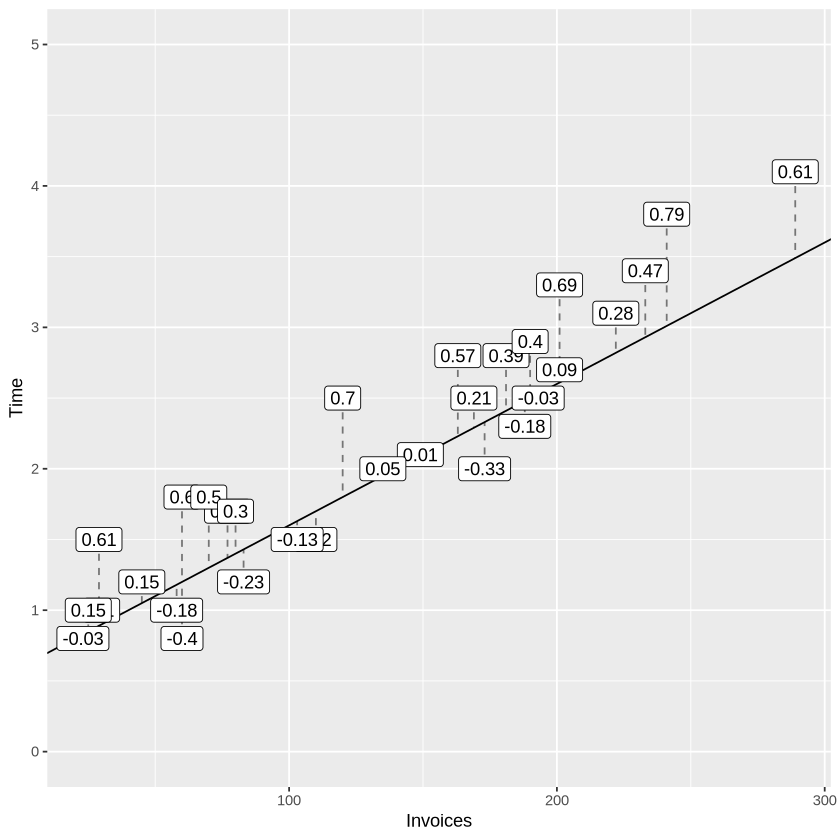

In [12]:
#| label: fig-residuals-strategy-2
#| fig-cap: "Prediction and Residuals for Strategy 2"
#| code-fold: true

dt %>%
    mutate(
        Time_predicted = 0.6 + 0.01 * Invoices,
        residuals = Time - Time_predicted
    ) %>%
ggplot(aes(x = Invoices, y = Time)) +
  geom_point() +
  geom_abline(intercept = 0.6, slope = 0.01) +
  ylim(c(0, 5)) +
  geom_segment(
    aes(
        xend = Invoices,
        yend = Time_predicted        
    ),
    alpha = 0.5,
    lty=2
    ) +
  geom_label(aes(label = round(residuals, 2)))

Which strategy is better? To answer this question we need to agree on a criterion for comparison. The criterion should be a summary of the differences between the actual and the predicted values and should be small when the differences are small. It should also be zero when the predictions are perfect (i.e. no differences between predicted and actual values).

A candidate criterion could be the average residual:

$$
\frac{1}{n}\sum_{i = 1}^{n} (\text{Time}_i - \widehat{\text{Time}}_i)
$$

It suffers from a major drawback, however. Can you spot it?

A widely used criterion is the mean squared error (MSE) defined as the average of the squared residuals:

$$
\begin{align*}
\text{RSS} & = \sum_{i=1}^n (\text{Time}_i - \widehat{\text{Time}}_i)^2 \\
\text{MSE} & = \frac{1}{n} \text{RSS}
\end{align*}
$$

where $\widehat{\text{Time}}_i$ is the predicted time needed to process the invoices.

Let's calculate the average prediction error, RSS and MSE for the two strategies. *Hint*: use the summarize function and the variables holding the residuals.


In [ ]:
dt %>%
  summarize(
    avg_res_eq1 = mean(residuals_1),
    RSS_eq1 = sum(residuals_1^2),
    MSE_eq1 = mean(residuals_1^2),    
  )

## Least Squares

The previous discussion leads us to a question. Can we find values for the coefficients in the linear equation that minimize the MSE? The answer is yes. The method is called least squares.

First, let us visualize the MSE as a function of the coefficients. For this purpose, we will simply calculate the MSE for a grid of values of the coefficients and plot the results (@fig-rss-beta0)

Our goal is to find the values of $\beta_0$ and $\beta_1$ that minimize the RSS. The method of least squares provides a formula for the coefficients that minimize the RSS.

First, let us solve a simpler problem. Assume that the predictive equation is

$$
\widehat{\text{Time}}_i = \hat{\beta}_0
$$

The MSE in this case is much simpler.

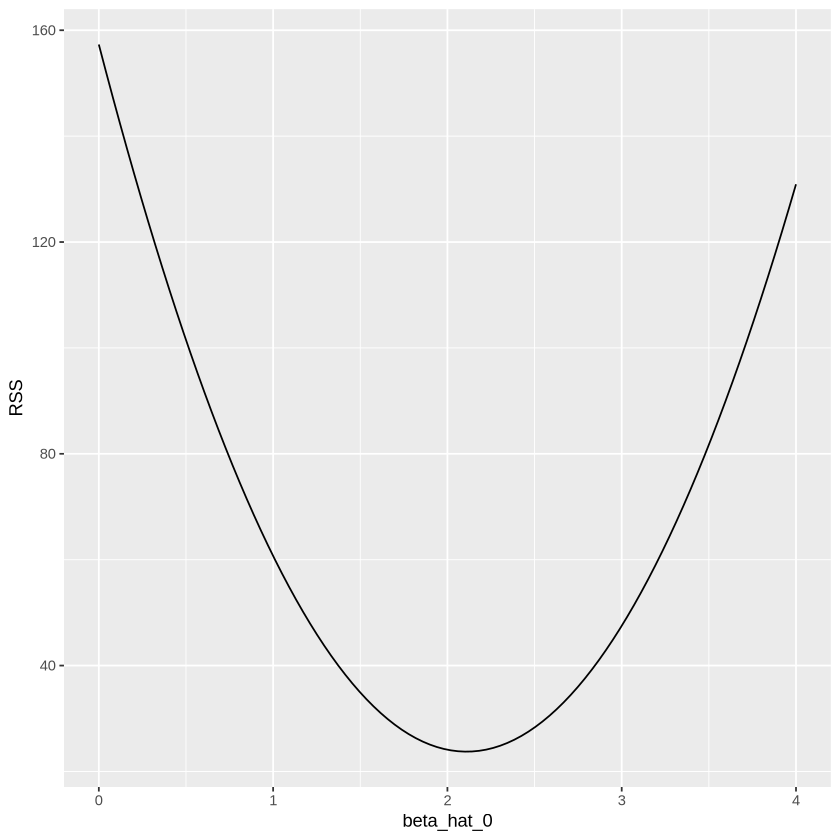

In [13]:
#| label: fig-rss-beta0
#| fig-cap: "MSE as a function of beta_hat_0 in an intercept-only equation"

rss_intercept_dt <- expand_grid(
    beta_hat_0 = seq(0, 4, length.out = 100),
    dt
)

rss_dt <- rss_intercept_dt %>%
  group_by(beta_hat_0) %>%
  summarise(
    RSS = sum((Time - beta_hat_0)^2)
  )

rss_dt %>%
    ggplot(aes(x = beta_hat_0, y = RSS)) +
    geom_line()

How do we find the value of $\hat{\beta}_0$ that minimizes the MSE? We take the derivative of the MSE with respect to $\hat{\beta}_0$ and set it to zero.

In order to find the minimum of the MSE, we take the derivative of the MSE with respect to $\hat{\beta}_0$ and set it to zero. Instead of $\text{Time}$ we will use the shorter notation $y_i$ and instead of $\hat{\text{Time}}_i$ we will use the shorter notation $\hat{y}_i$.

$$
\begin{align*}
RSS(\hat{\beta}_0) & = \sum_{i=1}^n (y_i - \hat{y}_i)^2 \\
 & = \sum_{i=1}^n (y_i - \hat{\beta}_0)^2
\end{align*}
$$

Try to find the value of $\hat{\beta}_0$ that minimizes the MSE. **Hint**: Take the derivative of the RSS with respect to $\hat{\beta}_0$, set it to zero and solve for $\hat{\beta}_0$.

::: {.callout-note collapse="true"}
## Solution for the intercept-only equation

$$
\begin{align*}
\frac{\partial}{\partial \hat{\beta}_0} RSS(\hat{\beta}_0) & = 
\sum_{i=1}^n 2(y_i - \hat{\beta}_0) \cdot (-1) \\
& = -2 \sum_{i=1}^n (y_i - \hat{\beta}_0) \\
& = -2 \sum_{i=1}^n y_i + 2 \sum_{i=1}^n \hat{\beta}_0 \\
& = -2 \sum_{i=1}^n y_i + 2 n \hat{\beta}_0
\end{align*}
$$

Setting the derivative to zero, we get

$$
\begin{align*}
-2 \sum_{i=1}^n y_i + 2 n \hat{\beta}_0 & = 0 \\
\hat{\beta}_0 & = \frac{1}{n} \sum_{i=1}^n y_i \\
& = \overline{y}
\end{align*}
$$

The value of $\hat{\beta}_0$ that minimizes the MSE is thus just the average of the observed values of $y_i$.
:::

If you find the above derivation hard to follow, try to write down the RSS for the intercept-only equation with only two observations. Then take the derivative with respect to $\hat{\beta}_0$ and set it to zero.

::: {.callout-note collapse="true"}
## Solution for the intercept-only equation with two observations

$$
\text{RSS}(\hat{\beta}_0) = (y_1 - \hat{\beta}_0)^2 + (y_2 - \hat{\beta}_0)^2
$$

The derivative of the RSS with respect to $\hat{\beta}_0$ is

$$
\begin{align*}
\frac{\partial}{\partial \hat{\beta}_0} \text{RSS}(\hat{\beta}_0) & = 2(y_1 - \hat{\beta}_0) \cdot (-1) + 2(y_2 - \hat{\beta}_0) \cdot (-1) \\
\end{align*}
$$

Set it to zero and solve for $\hat{\beta}_0$.

$$
\begin{align*}
2(y_1 - \hat{\beta}_0)(-1) + 2(y_2 - \hat{\beta}_0)(-1) & = 0 \quad \text{divide by -2 to simplify}\\ 
(y_1 - \hat{\beta}_0) + (y_2 - \hat{\beta}_0) & = 0 \\
y_1 - \hat{\beta}_0 + y_2 - \hat{\beta}_0 & = 0 \\
y_1 + y_2 - 2\hat{\beta}_0 & = 0 \\
2\hat{\beta}_0 & = y_1 + y_2 \\
\hat{\beta}_0 & = \frac{y_1 + y_2}{2}
\end{align*}
$$

Because there are now only two observations, their sum divided by two is their arithmetic average.
:::

::: {#exr-no-intercept-equation}
Consider the following equation for the predictions

$$
\hat{y} = \hat{\beta}_1 x
$$

Find the value of $\hat{\beta}_1$ that minimizes the RSS. **Hint**: Take the derivative of the RSS with respect to $\hat{\beta}_1$, set it to zero and solve for $\hat{\beta}_1$.
:::

## The one variable case with an intercept

Now let us consider the case where we have two variables, $\text{Invoices}_i$ and $\text{Time}_i$. We want to find the values of $\hat{\beta}_0$ and $\hat{\beta}_1$ that minimize the RSS.

The prediction equation is

$$
\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 x_i
$$

The RSS is again, the sum of the squared differences between observations ($y_i$) and predictions ($\hat{y}_i$).

$$
\begin{align*}
\text{RSS}(\hat{\beta}_0, \hat{\beta}_1) & = \sum_{i=1}^n (y_i - \hat{y}_i)^2 \\
  & = \sum_{i=1}^n (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2
\end{align*}
$$

This time the RSS depends on two variables ($\hat{\beta}_0$ and $\hat{\beta}_1$) and is a 3D surface. Again, we can set up two sequences of values for the two coefficients, calculate the RSS for each pair of values and plot the results [@fig-rss-3d].

In [15]:
#| label: fig-rss-3d
#| fig-cap: "RSS as a function of the coefficients"
#| code-fold: true

# NOTE: this code here is only for illustration purposes, you don't need to study it or understand it for the course
# Create a grid of values for beta_hat_0 and beta_hat_1

beta_hat_0 <- seq(0.4, 1, length.out = 50)
beta_hat_1 <- seq(0.001, 0.015, length.out = 50)

rss_two_coeffs <- expand.grid(beta_hat_0 = beta_hat_0, beta_hat_1 = beta_hat_1) %>%
  mutate(
    # Compute the RSS for each combination of beta_hat_0 and beta_hat_1
    RSS = map2_dbl(beta_hat_0, beta_hat_1, ~{
      Time_predicted <- .x + .y * dt$Invoices
      sum((dt$Time - Time_predicted)^2)
    })
  )

fig <- plot_ly(
  x=beta_hat_0, 
  y=beta_hat_1, 
  z = matrix(rss_two_coeffs$RSS, nrow = length(beta_hat_0), ncol = length(beta_hat_1)),
  ) %>% 
    add_surface() %>% 
    layout(
        scene = list(
          xaxis = list(title = "beta_hat_0"),
          yaxis = list(title = "beta_hat_1"),
          zaxis = list(title = "RSS")
        )
    )

fig

ERROR: Error in layout(., scene = list(xaxis = list(title = "beta_hat_0"), yaxis = list(title = "beta_hat_1"), : unused argument (scene = list(xaxis = list(title = "beta_hat_0"), yaxis = list(title = "beta_hat_1"), zaxis = list(title = "RSS")))
